# 🤖 LangGraph Agent Demo

This notebook demonstrates how to build agents with **LangGraph** — a framework for building stateful, multi-step AI applications as graphs.

## What we'll cover:
1. **Basic LangGraph concepts** — State, Nodes, Edges
2. **Simple chatbot** — A basic conversational agent
3. **Tool-calling agent** — Agent that uses tools (including an MCP server)
4. **Human-in-the-loop** — Adding breakpoints for human approval
5. **LangGraph Studio** — Running the agent in LangGraph Studio for visual debugging

## 0. Setup & Installation

In [1]:
%pip install langgraph langchain-openai langchain-core langchain-mcp-adapters python-dotenv --quiet

Note: you may need to restart the kernel to use updated packages.


In [2]:
import os
from dotenv import load_dotenv

load_dotenv()

# Make sure you have OPENAI_API_KEY set in your .env file or environment
assert os.getenv("OPENAI_API_KEY"), "Please set OPENAI_API_KEY in your .env file"
print("✅ API key loaded")

✅ API key loaded


---
## 1. LangGraph Core Concepts

LangGraph models applications as **graphs**:
- **State**: A shared data structure (usually a TypedDict) that flows through the graph
- **Nodes**: Python functions that read and update the state
- **Edges**: Define the flow between nodes (can be conditional)

```
     ┌──────────┐
     │  START    │
     └────┬─────┘
          │
     ┌────▼─────┐
     │  Node A   │ ──── (reads/writes state)
     └────┬─────┘
          │
     ┌────▼─────┐
     │  Node B   │ ──── (conditional edge)
     └────┬─────┘
         / \
        /   \
   ┌───▼┐  ┌▼───┐
   │ END │  │ A  │  (loop back)
   └─────┘  └────┘
```

### 1.1 Minimal Graph Example — Counter

Let's build the simplest possible graph: a counter that increments until it reaches 3.

In [3]:
from typing import TypedDict
from langgraph.graph import StateGraph, START, END

# 1. Define the State — what data flows through the graph
class CounterState(TypedDict):
    count: int

# 2. Define Nodes — functions that transform the state
def increment(state: CounterState) -> CounterState:
    print(f"  Incrementing: {state['count']} -> {state['count'] + 1}")
    return {"count": state["count"] + 1}

# 3. Define a conditional edge — decides where to go next
def should_continue(state: CounterState) -> str:
    if state["count"] < 3:
        return "increment"  # loop back
    return END               # done!

# 4. Build the graph
builder = StateGraph(CounterState)
builder.add_node("increment", increment)
builder.add_edge(START, "increment")
builder.add_conditional_edges("increment", should_continue)

graph = builder.compile()

# 5. Run it!
print("Running counter graph:")
result = graph.invoke({"count": 0})
print(f"\nFinal state: {result}")

Running counter graph:
  Incrementing: 0 -> 1
  Incrementing: 1 -> 2
  Incrementing: 2 -> 3

Final state: {'count': 3}


In [4]:
graph = builder.compile()
result = graph.invoke({"count": 4})
print(f"\nFinal state: {result}")

  Incrementing: 4 -> 5

Final state: {'count': 5}


### 1.2 Visualize the Graph

LangGraph can render graphs as images — very useful for understanding flow.

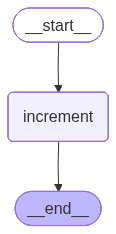

In [5]:
from IPython.display import Image, display

# Render the graph as a Mermaid diagram (PNG)
Image(graph.get_graph().draw_mermaid_png())

---
## 2. Simple Chatbot with LangGraph

Now let's build a real chatbot! We'll use `MessagesState` — a built-in state that manages a list of chat messages with automatic message appending.

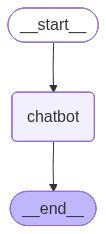

In [6]:
from langgraph.graph import StateGraph, START, END, MessagesState
from langchain_openai import ChatOpenAI

# Initialize the LLM
llm = ChatOpenAI(model="gpt-4o-mini", temperature=0)

# Node: call the LLM with the conversation history
def chatbot(state: MessagesState):
    response = llm.invoke(state["messages"])
    return {"messages": [response]}

# Build the graph: START -> chatbot -> END
builder = StateGraph(MessagesState)
builder.add_node("chatbot", chatbot)
builder.add_edge(START, "chatbot")
builder.add_edge("chatbot", END)

simple_chatbot = builder.compile()

# Visualize
display(Image(simple_chatbot.get_graph().draw_mermaid_png()))

In [7]:
# Test the chatbot
from langchain_core.messages import HumanMessage
from pprint import pprint

response = simple_chatbot.invoke({
    "messages": [HumanMessage(content="What is LangGraph in 2 sentences?")]
})

# Print the assistant's response
pprint(response["messages"][-1].content)

('LangGraph is a framework designed to facilitate the development of '
 'applications that leverage large language models (LLMs) by integrating them '
 'with graph-based data structures. It enables users to create, manipulate, '
 'and query knowledge graphs while harnessing the capabilities of LLMs for '
 'natural language understanding and generation.')


---
## 3. Tool-Calling Agent (ReAct Pattern)

The real power of LangGraph comes from building **agents** — LLMs that can decide which tools to use.

We use `create_agent` from `langchain.agents` (the new API replacing the deprecated `create_react_agent`).

The **ReAct** (Reason + Act) pattern:
1. LLM receives the user message
2. LLM decides to call a tool (or respond directly)
3. Tool executes and returns results
4. LLM sees the tool results and decides next step
5. Repeat until the LLM is ready to give a final answer

```
          ┌───────────┐
          │   agent    │ (LLM decides)
          └─────┬─────┘
               / \
     has tools/   \no tools
             /     \
     ┌──────▼──┐   ▼
     │  tools   │  END
     └──────┬──┘
            │
            └──→ back to agent
```

In [8]:
from langchain_core.tools import tool
from langgraph.prebuilt import create_react_agent
import math
import datetime

# Define custom tools
@tool
def get_weather(city: str) -> str:
    """Get the current weather for a city. Returns temperature and conditions."""
    # Simulated weather data for demo
    weather_data = {
        "tel aviv": "☀️ 28°C, Sunny",
        "new york": "🌧️ 15°C, Rainy",
        "london": "☁️ 12°C, Cloudy",
        "tokyo": "🌤️ 22°C, Partly cloudy",
    }
    return weather_data.get(city.lower(), f"🌡️ 20°C, No data for {city}")


@tool
def calculator(expression: str) -> str:
    """Evaluate a mathematical expression. Supports basic arithmetic and math functions.
    Examples: '2 + 2', 'sqrt(16)', 'sin(3.14)', '2**10'"""
    try:
        # Safe eval with only math functions
        allowed = {k: v for k, v in math.__dict__.items() if not k.startswith("_")}
        allowed.update({"abs": abs, "round": round})
        result = eval(expression, {"__builtins__": {}}, allowed)
        return str(result)
    except Exception as e:
        return f"Error: {e}"


@tool
def get_current_time() -> str:
    """Get the current date and time."""
    now = datetime.datetime.now()
    return now.strftime("%Y-%m-%d %H:%M:%S (%A)")


tools = [get_weather, calculator, get_current_time]
print(f"✅ Defined {len(tools)} tools: {[t.name for t in tools]}")

✅ Defined 3 tools: ['get_weather', 'calculator', 'get_current_time']


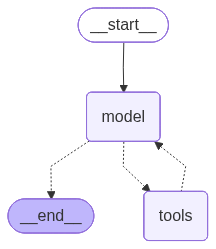

In [9]:
# Create an agent using the new create_agent API (replaces deprecated create_react_agent)
# This automatically creates the agent node, tool node, and conditional edges
from langchain.agents import create_agent

agent = create_agent(
    model=ChatOpenAI(model="gpt-4o-mini", temperature=0),
    tools=tools,
    system_prompt="You are a helpful assistant. Use tools when needed. Be concise."
)

# Visualize the agent graph
display(Image(agent.get_graph().draw_mermaid_png()))

In [10]:
# Test 1: Simple question (no tools needed)
response = agent.invoke({
    "messages": [HumanMessage(content="What is the capital of France?")]
})
print("Q: What is the capital of France?")
print(f"A: {response['messages'][-1].content}")
print()

Q: What is the capital of France?
A: The capital of France is Paris.



In [11]:
# Test 2: Multi-tool usage — the agent will use multiple tools to answer
response = agent.invoke({
    "messages": [HumanMessage(
        content="What's the weather in Tel Aviv and what's the square root of 144? Also, what time is it?"
    )]
})

# Show the full message trace to see tool calls
print("=== Full message trace ===")
for msg in response["messages"]:
    role = msg.__class__.__name__.replace("Message", "")
    if hasattr(msg, "tool_calls") and msg.tool_calls:
        print(f"\n🤖 {role}: [calling tools: {[tc['name'] for tc in msg.tool_calls]}]")
    elif hasattr(msg, "name") and msg.name:
        print(f"\n🔧 Tool ({msg.name}): {msg.content}")
    else:
        print(f"\n{'👤' if 'Human' in role else '🤖'} {role}: {msg.content}")

=== Full message trace ===

👤 Human: What's the weather in Tel Aviv and what's the square root of 144? Also, what time is it?

🤖 AI: [calling tools: ['get_weather', 'calculator', 'get_current_time']]

🔧 Tool (get_weather): ☀️ 28°C, Sunny

🔧 Tool (calculator): 12.0

🔧 Tool (get_current_time): 2026-03-23 19:57:27 (Monday)

🤖 AI: The weather in Tel Aviv is 28°C and sunny. The square root of 144 is 12. The current time is 19:57:27 on Monday, March 23, 2026.


In [12]:
pprint(response["messages"])

[HumanMessage(content="What's the weather in Tel Aviv and what's the square root of 144? Also, what time is it?", additional_kwargs={}, response_metadata={}, id='da5b2e71-b92a-4341-802f-1a1795ee2426'),
 AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 61, 'prompt_tokens': 152, 'total_tokens': 213, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_ca3e7d71bf', 'id': 'chatcmpl-DMdokG9Uc0rNqeRuMZ4sVDSyfWUz7', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019d1bd8-2f19-7b23-a894-115a2e62e39c-0', tool_calls=[{'name': 'get_weather', 'args': {'city': 'Tel Aviv'}, 'id': 'call_JdAH6uuSSOgdmZ3ssBkCXJGH', 'type': 'tool_call'}, {'name': 'calcula

---
## 4. Streaming — Watch the Agent Think in Real Time

LangGraph supports streaming so you can see each step as it happens.

In [13]:
# Stream events to see each step
print("=== Streaming agent steps ===\n")

for event in agent.stream(
    {"messages": [HumanMessage(content="What's 2^10 and what's the weather in London?")]},
    stream_mode="updates"
):
    for node_name, node_output in event.items():
        print(f"--- Step: {node_name} ---")
        last_msg = node_output["messages"][-1]
        if hasattr(last_msg, "tool_calls") and last_msg.tool_calls:
            for tc in last_msg.tool_calls:
                print(f"  🔧 Calling: {tc['name']}({tc['args']})")
        else:
            print(f"  💬 {last_msg.content[:200]}")
        print()

=== Streaming agent steps ===

--- Step: model ---
  🔧 Calling: calculator({'expression': '2**10'})
  🔧 Calling: get_weather({'city': 'London'})

--- Step: tools ---
  💬 1024

--- Step: tools ---
  💬 ☁️ 12°C, Cloudy

--- Step: model ---
  💬 The result of \(2^{10}\) is 1024. The current weather in London is 12°C and cloudy.



---
## 5. Human-in-the-Loop — Pause Before Tool Execution

LangGraph supports **interrupt_before** — pause the graph before a node runs, letting a human approve or reject the action. This is critical for production agents!

In [14]:
from langgraph.checkpoint.memory import MemorySaver

# Create agent with human-in-the-loop: pause BEFORE tools execute
checkpointer = MemorySaver()

agent_with_hitl = create_agent(
    model=ChatOpenAI(model="gpt-4o-mini", temperature=0),
    tools=tools,
    system_prompt="You are a helpful assistant.",
    checkpointer=checkpointer,
    interrupt_before=["tools"],  # ← Pause before tool execution!
)

# Start a conversation (needs a thread_id for checkpointing)
config = {"configurable": {"thread_id": "demo-1"}}

print("Sending message to agent...")
result = agent_with_hitl.invoke(
    {"messages": [HumanMessage(content="What's the weather in Tokyo?")]},
    config=config
)

# The agent is now PAUSED before calling the weather tool
last_msg = result["messages"][-1]
print(f"\n⏸️  Agent paused! It wants to call:")
for tc in last_msg.tool_calls:
    print(f"   🔧 {tc['name']}({tc['args']})")
print("\nThe graph is waiting for human approval...")

Sending message to agent...

⏸️  Agent paused! It wants to call:
   🔧 get_weather({'city': 'Tokyo'})

The graph is waiting for human approval...


In [15]:
# Resume execution — approve the tool call by passing None (continue as-is)
print("✅ Approving tool execution...\n")

result = agent_with_hitl.invoke(None, config=config)  # None = continue
print(f"🤖 Agent: {result['messages'][-1].content}")

✅ Approving tool execution...

🤖 Agent: The weather in Tokyo is currently 22°C and partly cloudy.
